# Basic setup

In [35]:
import numpy as np
import pandas as pd
import pingouin as pg
from scipy import stats
from statsmodels.stats.power import TTestPower
import seaborn as sns
import matplotlib.pyplot as plt
from palmerpenguins import load_penguins

In [2]:
sns.set_theme(style="whitegrid", palette="Set2")

In [3]:
data = pd.DataFrame()
data = load_penguins()

# Exploration

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB


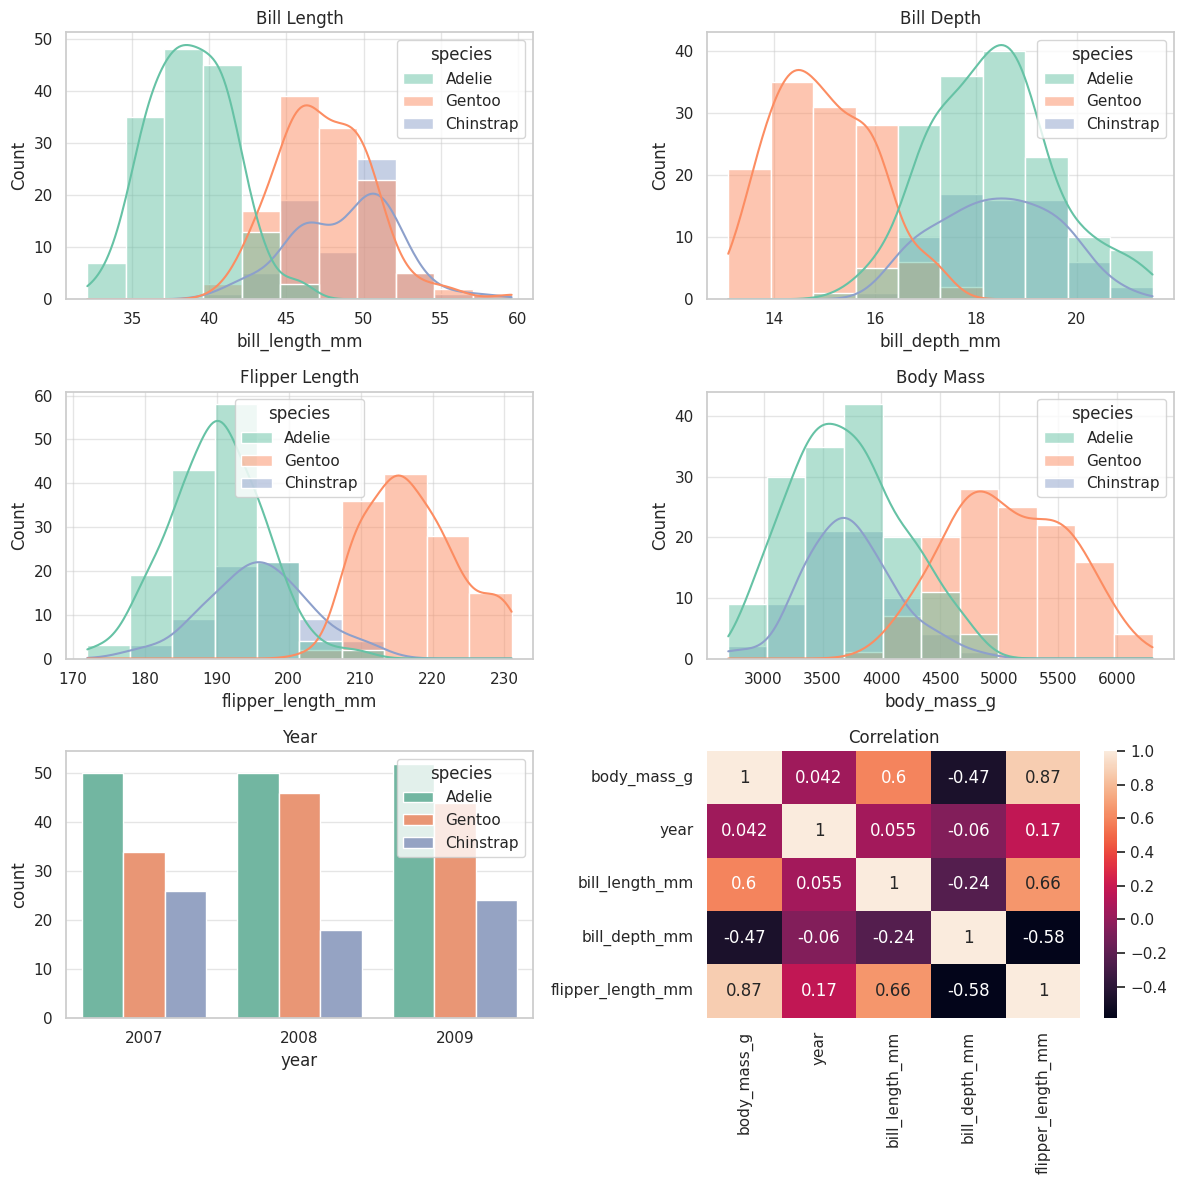

In [5]:
# Ax level plots

fig, ax = plt.subplots(3, 2, figsize=(12, 12))

sns.histplot(data, x="bill_length_mm", hue="species", kde=True, ax=ax[0,0])
ax[0,0].set_title('Bill Length')

sns.histplot(data, x="bill_depth_mm", hue="species", kde=True, ax=ax[0,1])
ax[0,1].set_title('Bill Depth')

sns.histplot(data, x="flipper_length_mm", hue="species", kde=True, ax=ax[1,0])
ax[1,0].set_title('Flipper Length')

sns.histplot(data, x="body_mass_g", hue="species", kde=True, ax=ax[1,1])
ax[1,1].set_title('Body Mass')

sns.countplot(data, x="year", hue="species", ax=ax[2,0])
ax[2,0].set_title('Year')

sns.heatmap(data.loc[:, ['body_mass_g', 'year', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']].corr(), annot=True, ax=ax[2,1])
ax[2,1].set_title('Correlation')

plt.tight_layout()
plt.show()

# Experiments

## Statistical power

An A/B testing experiment is being developed to see if a new diet could increase the weight of the Adelie species by 100 grams. What is the statistical power if we can only sample 200 penguins?

In [6]:
# Adelie species parameters
ade_mean = np.mean(data.query('species == "Adelie"').body_mass_g)
ade_std = np.std(data.query('species == "Adelie"').body_mass_g, ddof=1) # degree of freedom = n - 1 since we are using the sample from the dataset
alpha = 0.05
target_weight = 3800
sample = 200

In [7]:
# Manual calculation

sem = ade_std / np.sqrt(sample)
x_critical = ade_mean + sem * stats.t.ppf(1 -alpha, df=sample - 1)
t_score = (x_critical - target_weight) / sem
power = stats.t.sf(t_score, df=sample - 1)

print(f'The statistical power is {power:.4%}')

The statistical power is 92.0100%


If the A/B experiment's goal is to identify a small difference in weight, the number of samples would have to be higher

In [8]:
# Using the package

# One important difference is that the Cohen's d must be calculatted
cohen_d = float((target_weight - ade_mean) / ade_std)

# Calculating the statistical power
power_analysis = TTestPower()
solution = power_analysis.solve_power(effect_size=cohen_d, nobs=sample, alpha=alpha, alternative='larger')
print(f'The statistical power is {solution:.4%}')

# If I would like to know the sample size based on a desired power of 80%
sample_size = power_analysis.solve_power(power=0.90, effect_size=cohen_d, alpha=alpha, alternative='larger')
print(f'\nThe sample size required is {sample_size:.0f}')

The statistical power is 92.0475%

The sample size required is 184


## Hypothesis testing

### Hypothesis testing of the mean - One sample

In the 90's, the average gentoo penguin weight was 4.9 Kg. Has this change based on the sample?

In [10]:
# Manual calculation
gentoo_mean = data.query('species == "Gentoo"').body_mass_g.mean()
print(f'The average Gentoo penguin weight was {gentoo_mean:,.2f} grams')
gentoo_size = data.query('species == "Gentoo"').shape[0]
gentoo_std = np.std(data.query('species == "Gentoo"').body_mass_g, ddof=1)
h0 = 4900

sem = gentoo_std / np.sqrt(gentoo_size)
t_test = (gentoo_mean - h0) / sem
p_value = stats.t.sf(np.abs(t_test), df=gentoo_size - 1) * 2 # Two-sided test
print(f'The p-value is {p_value:.4%}. Hence, H0 is rejected and conclude that the average weight of Gentoo penguins has changed from {h0} grams.')


The average Gentoo penguin weight was 5,076.02 grams
The p-value is 0.0164%. Hence, H0 is rejected and conclude that the average weight of Gentoo penguins has changed from 4900 grams.


In [11]:
# Using the package

t_stat, p_value = stats.ttest_1samp(a=data.query('species == "Gentoo"')['body_mass_g'].dropna(), popmean=4900, alternative='two-sided')
print(f'The t statistic is {t_stat} and the p_value is {p_value:.4%}.')

The t statistic is 3.872350495988591 and the p_value is 0.0175%.


Hence, H0 is rejected and the average weight of the Gentoo penguins has changes since the 90s

In [12]:
# Just in case, checking the statistical power
# THIS IS A WRONG APPROACH AS THE SAMPLE DATA IS BEING USED. INSTEAD, THE CONFIDENCE INTERVAL COULD BE EFFECTIVE

cohen_d = float(gentoo_mean - h0) / gentoo_std

# Calculating the statistical power
power_analysis = TTestPower()
statistical_power = power_analysis.solve_power(effect_size=cohen_d, nobs=gentoo_size, alpha=0.05, alternative='two-sided')
print(f'The statistical power is {statistical_power:.4%}.')

The statistical power is 97.1123%.


### Hypothesis testing of the mean - Two samples

This test is basially to understand if wheter 2 samples come from the same population

Is there a statistically significant difference in the average body mass of Adelie penguins living on Torgersen Island compared to those on Biscoe Island?

In [13]:
sample1 = data[(data.species == 'Adelie') & (data.island == 'Torgersen')].body_mass_g.dropna()
sample2 = data[(data.species == 'Adelie') & (data.island == 'Biscoe')].body_mass_g.dropna()

t_stat, p_value = stats.ttest_ind(sample1, sample2, equal_var=False, alternative='two-sided')
# equal_var = False means to use Welch's t-test' which does not assume equal variance
print(f'The t statistic is {t_stat} and the p_value is {p_value:.4%}.')

The t statistic is -0.034096013235371626 and the p_value is 97.2878%.


These 2 samples from Adelie penguins from two different islands show that they come from the population as there is no significant difference in their average eight

### Hypothesis testing of the mean - More than two samples

Is there a significant difference in the mean weight across the three different species?

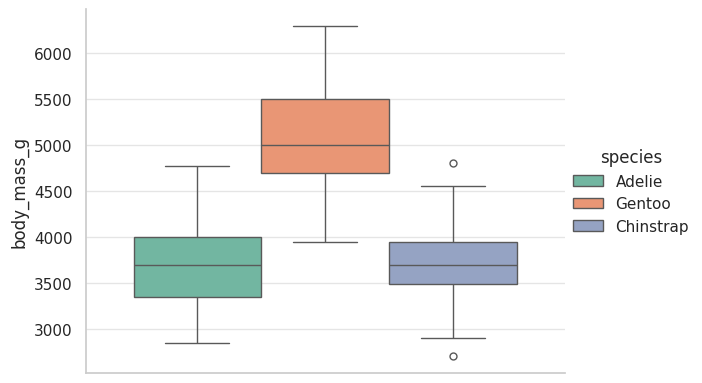

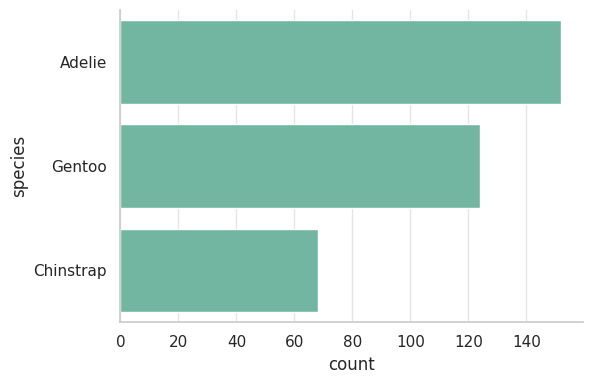

In [27]:
# Checking if there are severe outliers

sns.catplot(data=data, y='body_mass_g', kind='box', height=4, aspect=1.5, hue='species', palette='Set2')

# Checking the sample size
sns.catplot(data=data, y='species', kind='count', height=4, aspect=1.5)

In [31]:
group_one = data[data.species == 'Adelie'].body_mass_g.dropna()
group_two = data[data.species == 'Gentoo'].body_mass_g.dropna()
group_three = data[data.species == 'Chinstrap'].body_mass_g.dropna()

f_statistic, p_value = stats.f_oneway(group_one, group_two, group_three, equal_var=False)
print(f'The F statistic is {f_statistic} and the p_value is {p_value:.4%}.')

The F statistic is 317.572267104156 and the p_value is 0.0000%.


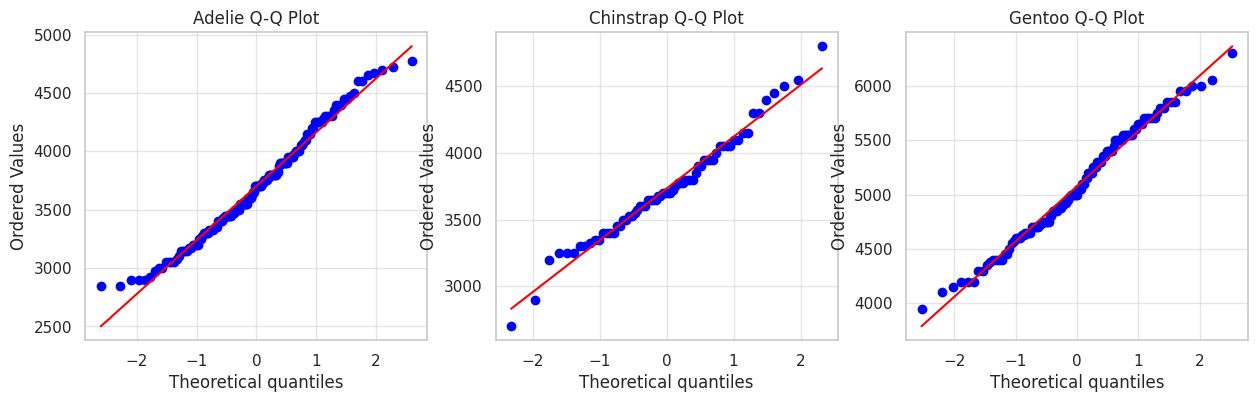

Adelie Shapiro P-value: 0.0324
Chinstrap Shapiro P-value: 0.5605
Gentoo Shapiro P-value: 0.2336


In [32]:
# 1. Extract the 3 groups
adelie = data.query('species == "Adelie"').body_mass_g.dropna()
chinstrap = data.query('species == "Chinstrap"').body_mass_g.dropna()
gentoo = data.query('species == "Gentoo"').body_mass_g.dropna()

# 2. The Visual Test: Q-Q Plots
# A Q-Q plot forces perfectly normal data to form a straight 45-degree diagonal line.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
stats.probplot(adelie, dist="norm", plot=axes[0])
axes[0].set_title('Adelie Q-Q Plot')

stats.probplot(chinstrap, dist="norm", plot=axes[1])
axes[1].set_title('Chinstrap Q-Q Plot')

stats.probplot(gentoo, dist="norm", plot=axes[2])
axes[2].set_title('Gentoo Q-Q Plot')
plt.show()

# 3. The Math Test: Shapiro-Wilk
# H0: The data is perfectly normal. (We WANT the P-value to be > 0.05!)
print(f"Adelie Shapiro P-value: {stats.shapiro(adelie).pvalue:.4f}")
print(f"Chinstrap Shapiro P-value: {stats.shapiro(chinstrap).pvalue:.4f}")
print(f"Gentoo Shapiro P-value: {stats.shapiro(gentoo).pvalue:.4f}")

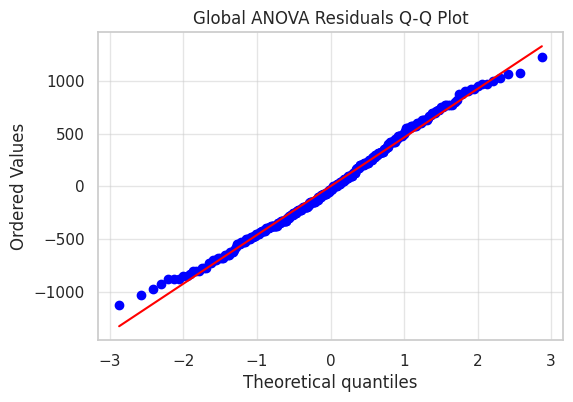

Global Residuals Shapiro P-value: 0.0512


In [37]:
# Residual validation (best option)

from statsmodels.formula.api import ols

# 1. Build the ANOVA Model (The GLM Engine)
# "Predict body_mass_g using the Categorical (C) variable 'species'"
model = ols('body_mass_g ~ C(species)', data=data).fit()

# 2. Extract the Universal Residuals
# The model calculates every single penguin's distance from its group mean
global_residuals = model.resid

# 3. The Visual Test (One Q-Q Plot for the whole model)
fig, ax = plt.subplots(figsize=(6, 4))
stats.probplot(global_residuals, dist="norm", plot=ax)
ax.set_title('Global ANOVA Residuals Q-Q Plot')
plt.show()

# 4. The Math Test (One Shapiro Test for the whole model)
shapiro_test = stats.shapiro(global_residuals)
print(f"Global Residuals Shapiro P-value: {shapiro_test.pvalue:.4f}")

In [36]:
# Pingouin automatically defaults to Welch's ANOVA!
anova_results = pg.welch_anova(dv='body_mass_g', between='species', data=data)

print(anova_results)

    Source  ddof1       ddof2           F         p_unc       np2
0  species      2  189.478413  317.572267  3.093701e-61  0.669672


- Issues with ANOVA scipy (Welch). Pingouin as an alternative
- Validation of the residual normal distribution: formal and shortcut
- Rule of thumb shortcuts: n>30 and no significant outliers

## Linear regression

## Classification

# DRAFT

In [ ]:
# TODO: pair-wise with and without Bofferoni

In [42]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.670
Model:                            OLS   Adj. R-squared:                  0.668
Method:                 Least Squares   F-statistic:                     343.6
Date:                Mon, 06 Apr 2026   Prob (F-statistic):           2.89e-82
Time:                        01:59:40   Log-Likelihood:                -2582.3
No. Observations:                 342   AIC:                             5171.
Df Residuals:                     339   BIC:                             5182.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                3700.6623     37.619     98.371      0.000    3626.665    3774.659
C(species)[T.Chinstrap]    32.4260     67.512      0.480      0.631    -100.369     165.221
C(species)[T.Gentoo]     1375.3540     56.148     24.495      0.000    1264.912    1485.796
==============================================================================
Omnibus:                        7.340   Durbin-Watson:                   3.036
Prob(Omnibus):                  0.025   Jarque-Bera (JB):                5.331
Skew:                           0.182   Prob(JB):                       0.0696
Kurtosis:                       2.508   Cond. No.                         3.45
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [14]:
data.species.value_counts()

species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

In [ ]:
data[data.body_mass_g.isna()]

In [ ]:
data.query('species == "Gentoo"').shape[0]

In [ ]:
data.query('species == "Adelie"').body_mass_g.mean()